# 02 — Engenharia de features

Duas etapas, separadas de propósito:

1. **Painel** (`features.painel_diario`): 122 mil incidentes viram uma tabela entidade × dia com
   volume, severidade, OLA, MTTR e alcance.
2. **Matriz** (`features.construir_features`): o painel vira uma linha por
   (entidade, dia de origem, horizonte), com o alvo em `t + h`.

A decisão estrutural deste notebook é tratar o problema como **painel**, e não como uma série
global única.

In [1]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings('ignore')
RAIZ = Path.cwd().parents[1] if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(RAIZ))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)
plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

from ml.src import config, dataset, explain, features, metrics, models_zoo, registry, selecao, splits, train
print('Banco:', config.BANCO, '| existe:', config.BANCO.exists())

Banco: C:\Users\Usuario\Downloads\CP\sentinel_ops\db.sqlite3 | existe: True


In [2]:
base = train.preparar_base(verbose=True)
painel, matriz = base['painel'], base['matriz']

Regime operacional detectado a partir de 2025-01-13 (120,670 incidentes, 55 entidades).
Matriz de features: 122,507 linhas × 85 features.


## Por que painel, e não uma série só

Com uma linha por dia, o histórico útil daria ~350 exemplos — pouco para qualquer modelo com
dezenas de features. Somando produtos, equipes e categorias como entidades, o mesmo mapa
lag → alvo é aprendido sobre dezenas de milhares de linhas, e o modelo passa a saber prever
**por grupo** — que é o que a operação precisa para agir.

In [3]:
print('Entidades por dimensão:')
display(painel.groupby('dimensao')['chave'].nunique())
print('\nLinhas do painel :', f'{len(painel):,}')
print('Linhas da matriz :', f'{len(matriz):,}')
print('Linhas por horizonte:')
display(matriz.groupby('horizonte').size())

Entidades por dimensão:


dimensao
categoria     12
equipe        12
global         1
item           8
prioridade     2
produto       20
Name: chave, dtype: int64


Linhas do painel : 19,316
Linhas da matriz : 122,507
Linhas por horizonte:


horizonte
1    17666
2    17611
3    17556
4    17501
5    17446
6    17391
7    17336
dtype: int64

In [4]:
painel[painel['dimensao'] == 'global'].tail(5)[
    ['data', 'total', 'total_kpi', 'criticos', 'p2', 'p3', 'violacoes', 'mttr_medio']
]

,data,total,total_kpi,criticos,p2,p3,violacoes,mttr_medio
8811,2025-12-27,1027.0,18.0,10.0,10.0,8.0,2.0,144.864815
8812,2025-12-28,829.0,12.0,7.0,7.0,5.0,0.0,198.642424
8813,2025-12-29,921.0,26.0,19.0,19.0,7.0,0.0,50.001923
8814,2025-12-30,866.0,10.0,5.0,5.0,5.0,0.0,77.393333
8815,2025-12-31,755.0,10.0,9.0,9.0,1.0,1.0,112.698333


## As famílias de features

83 features, todas numéricas e todas calculadas com dados até o dia de origem `t`.

In [5]:
colunas = features.colunas_de_features(matriz)

grupos = {
    'defasagens (lags)': [c for c in colunas if c.startswith('lag_')],
    'janelas agregadas': [c for c in colunas if c.startswith(('soma_', 'media_', 'desvio_', 'min_', 'max_'))],
    'dinâmica / tendência': [c for c in colunas if c in ('var_7_vs_7', 'razao_7_28', 'delta_media_7_14', 'cv_28', 'dias_ativos_28')],
    'sazonal (mesmo dia da semana)': [c for c in colunas if c.startswith('mesmo_dow') or c == 'media_mesmo_dow_4'],
    'calendário': [c for c in colunas if c in ('dow', 'dia_mes', 'mes', 'semana_ano', 'fim_de_semana', 'feriado', 'vespera_feriado', 'pos_feriado', 'dow_sin', 'dow_cos', 'mes_sin', 'mes_cos', 'dow_origem', 'horizonte')],
    'severidade': [c for c in colunas if 'critico' in c or c.startswith(('p2_', 'p3_'))],
    'OLA e MTTR': [c for c in colunas if 'violacao' in c or 'mttr' in c],
    'alcance e ruído': [c for c in colunas if 'itens_distintos' in c or 'familias_distintas' in c or 'ruido' in c or 'monitoramento' in c],
    'escala da entidade': [c for c in colunas if c in ('media_expandida', 'share_global_28') or c.startswith('dim_')],
}
for nome, itens in grupos.items():
    print(f'{nome:>32}: {len(itens):>2}  {", ".join(itens[:5])}{"..." if len(itens) > 5 else ""}')
print(f'\n{"TOTAL":>32}: {len(colunas)}')

               defasagens (lags): 14  lag_0, lag_1, lag_2, lag_3, lag_4...
               janelas agregadas: 18  soma_1, soma_2, soma_3, soma_7, soma_14...
            dinâmica / tendência:  5  var_7_vs_7, razao_7_28, delta_media_7_14, cv_28, dias_ativos_28
   sazonal (mesmo dia da semana):  5  mesmo_dow_1, mesmo_dow_2, mesmo_dow_3, mesmo_dow_4, media_mesmo_dow_4
                      calendário: 14  horizonte, dow, dia_mes, mes, semana_ano...
                      severidade:  7  criticos_media_7, criticos_media_28, p2_media_7, p2_media_28, p3_media_7...
                      OLA e MTTR:  6  mttr_medio_media_7, mttr_medio_media_28, taxa_violacao_media_7, taxa_violacao_media_28, delta_mttr...
                 alcance e ruído:  4  monitoramento_media_7, itens_distintos_media_7, familias_distintas_media_7, share_ruido_7
              escala da entidade:  8  media_expandida, share_global_28, dim_global, dim_produto, dim_equipe...

                           TOTAL: 85


## Verificação de vazamento

Três checagens objetivas, porque "achamos que não vaza" não é verificação:

1. Toda linha tem `data_alvo > data_origem`.
2. Nenhuma feature é o próprio alvo disfarçado — a correlação máxima com o alvo tem que ser
   compatível com defasagem, não com identidade.
3. O recorte temporal das partições não se sobrepõe.

In [6]:
print('1) data_alvo sempre no futuro da origem:',
      bool((matriz['data_alvo'] > matriz['data_origem']).all()))

X, y, ident = features.separar(matriz)
correlacoes = X.corrwith(y).abs().sort_values(ascending=False)
print('\n2) Features mais correlacionadas com o alvo:')
display(correlacoes.head(8).round(3))
print('Correlação máxima:', round(correlacoes.max(), 4),
      '— abaixo de 1,0, como esperado de defasagem (identidade daria 1,0).')

print('\n3) Partições temporais:')
display(pd.DataFrame(splits.descricao(matriz)).T)

1) data_alvo sempre no futuro da origem: True



2) Features mais correlacionadas com o alvo:


media_mesmo_dow_4    0.940
mesmo_dow_1          0.919
mesmo_dow_2          0.916
mesmo_dow_3          0.904
mesmo_dow_4          0.902
media_14             0.886
soma_14              0.886
media_28             0.885
dtype: float64

Correlação máxima: 0.9404 — abaixo de 1,0, como esperado de defasagem (identidade daria 1,0).

3) Partições temporais:


,linhas,inicio,fim
treino,100947,2025-02-12,2025-11-05
validacao,10780,2025-11-06,2025-12-03
teste,10780,2025-12-04,2025-12-31


### O que ficou deliberadamente de fora

- **Índice de tempo cru** (dias desde o início). Árvore não extrapola: um índice que só cresce
  vira uma porta para o modelo decorar o período em vez de aprender o padrão. O nível recente
  (`media_28`, `media_expandida`) cumpre o papel sem essa promessa falsa.
- **Qualquer campo de desfecho** — duração, data de resolução, status, código de fechamento.
  Nada disso existe no momento em que a previsão é feita.

## Clusterização — features que descrevem comportamento, não tamanho

Como parte da exploração, os produtos são agrupados por perfil operacional. O `k` é escolhido
pela silhueta, não no olho.

Artefato gravado: model_cluster | KMeans
Arquivo         : model_cluster.pkl


,k,silhueta,inercia
0,2,0.3212,90.47
1,3,0.2521,71.36
2,4,0.2744,53.47
3,5,0.2834,38.15
4,6,0.2717,29.36
5,7,0.2483,23.23


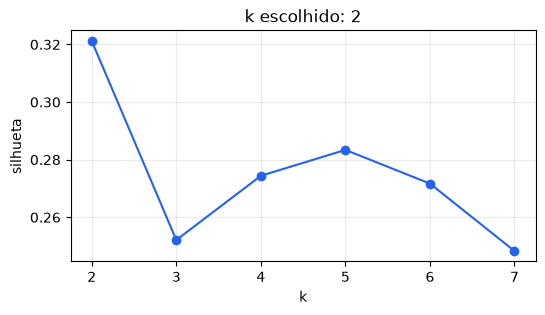

In [7]:
cartao_cluster = train.treinar_clusters(base)
print('Artefato gravado:', cartao_cluster['nome'], '|', cartao_cluster['algoritmo'])
print('Arquivo         :', registry.caminho_artefato(cartao_cluster['nome']).name)
busca = pd.DataFrame(cartao_cluster['metricas']['busca_k'])
display(busca)

fig, eixo = plt.subplots(figsize=(6, 3))
eixo.plot(busca['k'], busca['silhueta'], marker='o', color='#2563eb')
eixo.set_xlabel('k'); eixo.set_ylabel('silhueta')
eixo.set_title(f'k escolhido: {cartao_cluster["metricas"]["k_escolhido"]}')
plt.show()

In [8]:
for numero, grupo in cartao_cluster['grupos'].items():
    print(f'\nGrupo {numero} — {len(grupo["produtos"])} produtos: {", ".join(grupo["produtos"][:8])}')
    for campo, valor in grupo['perfil'].items():
        print(f'    {campo:>16}: {valor}')


Grupo 0 — 14 produtos: lcsi, lcsp, lemg, lemn, lexc, lgoa, lrdo, lrel
        volume_medio: 1.083
      share_criticos: 0.16
       taxa_violacao: 0.017
                mttr: 7091.204
         dias_ativos: 0.492
         share_ruido: 0.334
       instabilidade: 1.496

Grupo 1 — 6 produtos: lcem, lcho, lhco, lhvp, lrev, lsin
        volume_medio: 8.742
      share_criticos: 0.305
       taxa_violacao: 0.008
                mttr: 1943.778
         dias_ativos: 0.925
         share_ruido: 0.715
       instabilidade: 0.705
